# proyecto


In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Motor de base de datos reutilizando database.py del proyecto
from scripts.database import engine

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas       {pd.__version__}")
print(f"   numpy        {np.__version__}")
print(f"   seaborn      {sns.__version__}")
print(f"   statsmodels  {sm.__version__}")

✅ Librerías importadas correctamente
   pandas       2.3.3
   numpy        2.4.3
   seaborn      0.13.2
   statsmodels  0.14.4


In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL (Supabase) ─────────────────

QUERY = """
SELECT
    id,
    nombre,
    magnitud_absoluta,
    diametro_min_km,
    diametro_max_km,
    es_peligroso,
    velocidad_km_s,
    distancia_km,
    fecha_aproximacion,
    fecha_extraccion
FROM asteroides
ORDER BY fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados exitosamente desde Supabase")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

print("\n📋 Primeras filas:")
display(df.head())

✅ Datos cargados exitosamente desde Supabase
   Filas    : 300
   Columnas : 10

📋 Primeras filas:


,id,nombre,magnitud_absoluta,diametro_min_km,diametro_max_km,es_peligroso,velocidad_km_s,distancia_km,fecha_aproximacion,fecha_extraccion
0,1,330659 (2008 GG2),23.01,0.066459,0.148607,False,7.190266,2.205655e+07,2026-04-11,2026-04-11 00:52:27.102419+00:00
1,2,363599 (2004 FG11),21.05,0.163891,0.366471,True,25.071287,8.454616e+06,2026-04-11,2026-04-11 00:52:27.102558+00:00
2,3,(2017 GS6),24.80,0.029144,0.065169,False,17.306900,7.146886e+07,2026-04-11,2026-04-11 00:52:27.102571+00:00
3,4,(2017 UR5),28.70,0.004837,0.010815,False,8.500920,5.696653e+07,2026-04-11,2026-04-11 00:52:27.102580+00:00
4,5,(2019 GK3),29.50,0.003346,0.007482,False,5.538608,1.289511e+07,2026-04-11,2026-04-11 00:52:27.102587+00:00


In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)

print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print("\n📈 Estadísticas descriptivas:")
display(df.describe())

print("\n⚠️ Distribución de variable categórica (es_peligroso):")
print(df['es_peligroso'].value_counts())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   id                  300 non-null    int64              
 1   nombre              300 non-null    object             
 2   magnitud_absoluta   300 non-null    float64            
 3   diametro_min_km     300 non-null    float64            
 4   diametro_max_km     300 non-null    float64            
 5   es_peligroso        300 non-null    bool               
 6   velocidad_km_s      300 non-null    float64            
 7   distancia_km        300 non-null    float64            
 8   fecha_aproximacion  300 non-null    object             
 9   fecha_extraccion    300 non-null    datetime64[ns, UTC]
dtypes: bool(1), datetime64[ns, UTC](1), float64(5), int64(1), object(2)
memory usage: 21.5+ KB
None

📊 Valores nulos por columna

,id,magnitud_absoluta,diametro_min_km,diametro_max_km,velocidad_km_s,distancia_km
count,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02
mean,222.053333,25.076513,0.052674,0.117782,11.994267,2.933924e+07
std,134.895242,2.370861,0.096641,0.216097,6.074250,2.334601e+07
min,1.000000,17.410000,0.002262,0.005059,0.562827,1.402214e+05
25%,75.750000,23.775000,0.011987,0.026803,7.408018,8.377494e+06
50%,264.500000,25.400000,0.022109,0.049436,10.624997,2.327046e+07
75%,339.250000,26.729250,0.046735,0.104503,16.221925,4.906804e+07
max,414.000000,30.350000,0.876103,1.959025,28.447087,7.477857e+07



⚠️ Distribución de variable categórica (es_peligroso):
es_peligroso
False    281
True      19
Name: count, dtype: int64


In [26]:
import numpy as np

# Diámetro promedio
df['diametro_promedio_km'] = (df['diametro_min_km'] + df['diametro_max_km']) / 2

# Brillo relativo
df['brillo_relativo'] = -df['magnitud_absoluta']

# Raíz cuadrada SIN cambiar el nombre
df['raiz_diametro_promedio'] = np.sqrt(df['diametro_promedio_km'])

print("✅ Variables creadas correctamente")
display(df[['diametro_promedio_km']].head())

✅ Variables creadas correctamente


,diametro_promedio_km
0,0.107533
1,0.265181
2,0.047157
3,0.007826
4,0.005414


In [27]:
# ── CELDA 5: Estadísticas descriptivas (modelo Raiz) ──────────

vars_num = [
    'magnitud_absoluta',
    'diametro_min_km',
    'diametro_max_km',
    'velocidad_km_s',
    'distancia_km',
    'diametro_promedio_km'
]

desc = df[vars_num].describe().round(3)

print("📊 ESTADÍSTICAS DESCRIPTIVAS — MODELO RAIZ")
display(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS — MODELO RAIZ


,magnitud_absoluta,diametro_min_km,diametro_max_km,velocidad_km_s,distancia_km,diametro_promedio_km
count,300.000,300.000,300.000,300.000,3.000000e+02,300.000
mean,25.077,0.053,0.118,11.994,2.933924e+07,0.085
std,2.371,0.097,0.216,6.074,2.334601e+07,0.156
min,17.410,0.002,0.005,0.563,1.402214e+05,0.004
25%,23.775,0.012,0.027,7.408,8.377494e+06,0.019
50%,25.400,0.022,0.049,10.625,2.327046e+07,0.036
75%,26.729,0.047,0.105,16.222,4.906804e+07,0.076
max,30.350,0.876,1.959,28.447,7.477857e+07,1.418


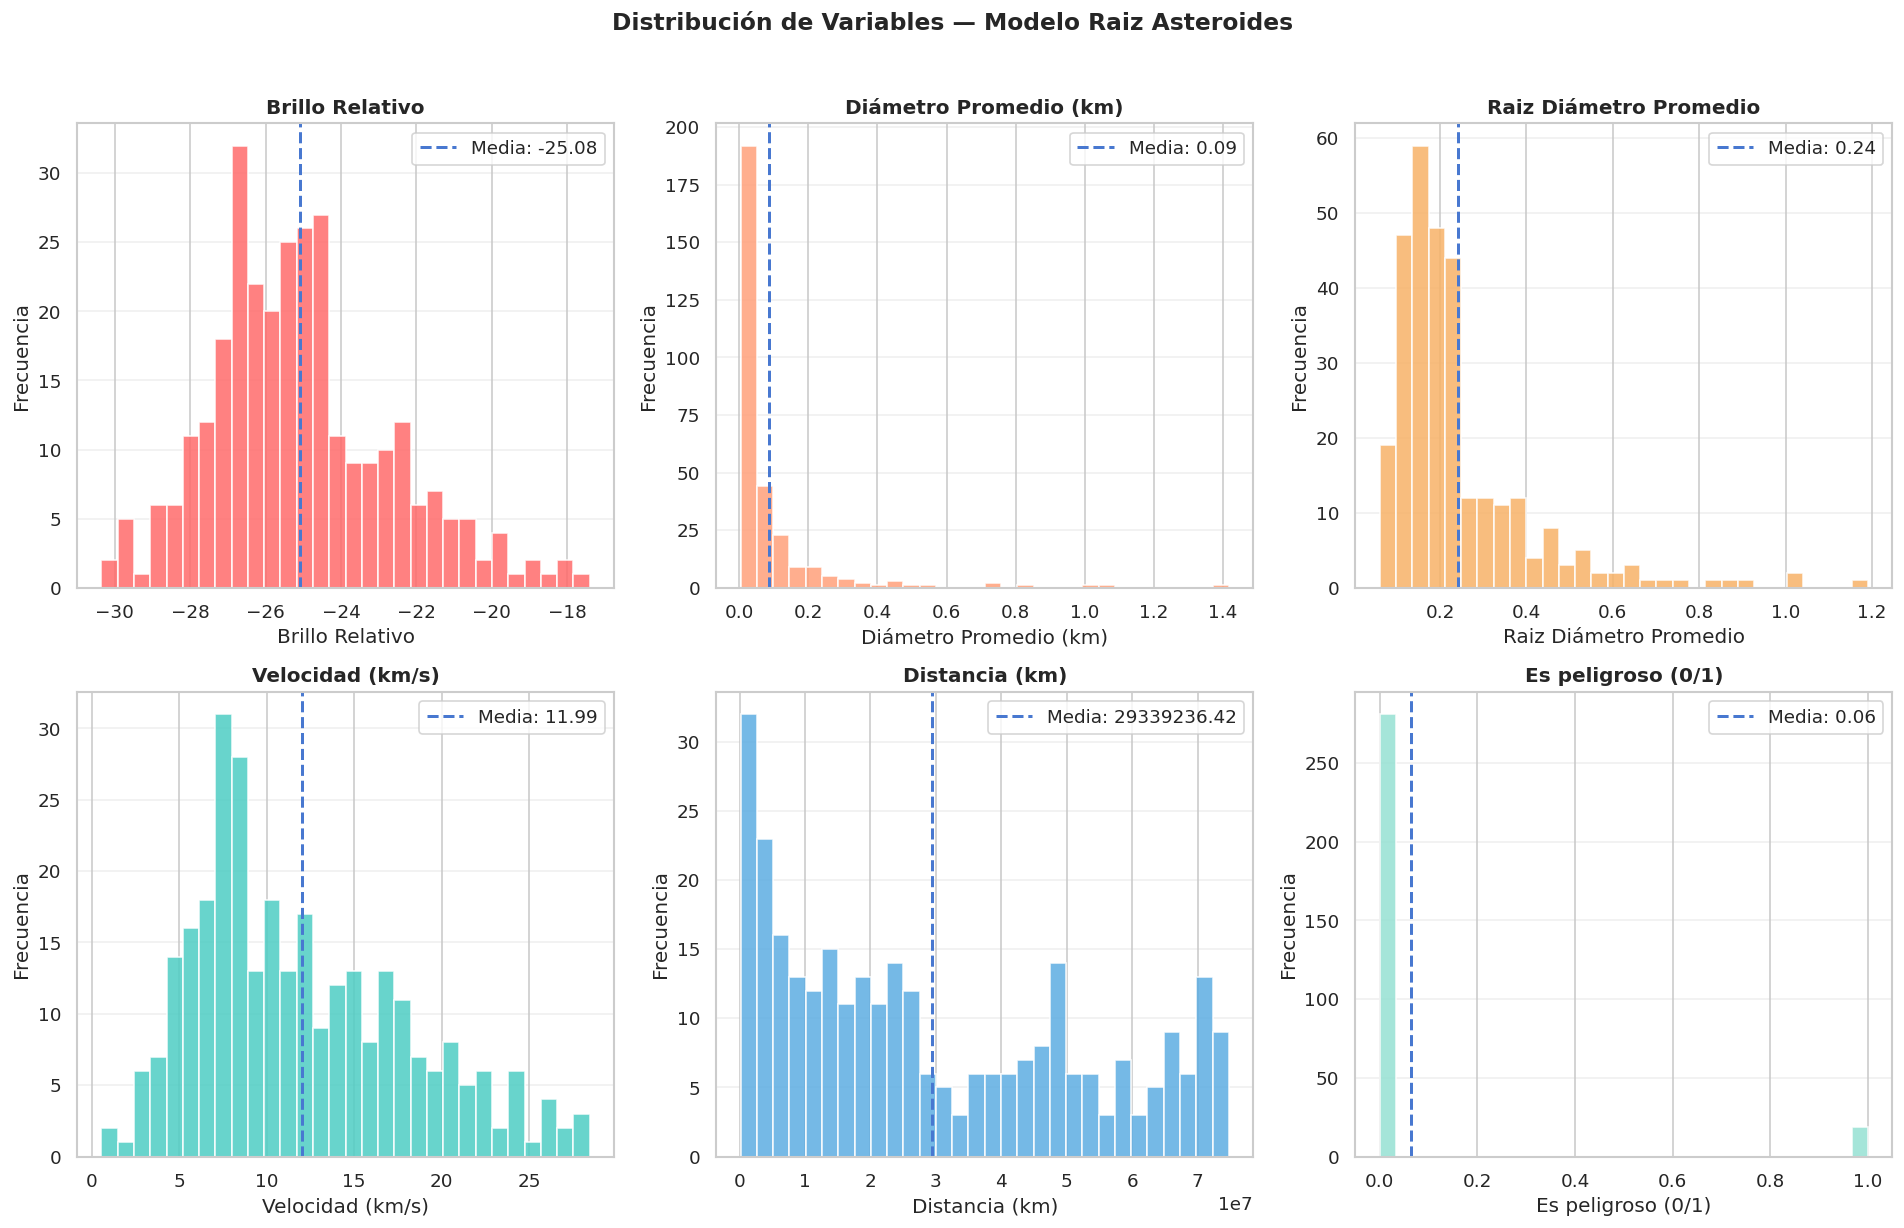

In [6]:
# ── CELDA 5: Histogramas de distribución (modelo raiz) ─────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Variables — Modelo Raiz Asteroides',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'brillo_relativo':        ('Brillo Relativo', '#ff6b6b'),
    'diametro_promedio_km':   ('Diámetro Promedio (km)', '#ffa07a'),
    'raiz_diametro_promedio':  ('Raiz Diámetro Promedio', '#f7b267'),
    'velocidad_km_s':         ('Velocidad (km/s)', '#4ecdc4'),
    'distancia_km':           ('Distancia (km)', '#5dade2'),
    'es_peligroso_num':       ('Es peligroso (0/1)', '#95e1d3')
}

# Convertimos es_peligroso a numérico (si no existe aún)
if 'es_peligroso_num' not in df.columns:
    df['es_peligroso_num'] = df['es_peligroso'].astype(int)

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    
    data = df[col]
    
    ax.hist(data, bins=30, edgecolor='white', alpha=0.85, color=color)
    
    media = data.mean()
    ax.axvline(media, linestyle='--', linewidth=1.8,
               label=f'Media: {media:.2f}')
    
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


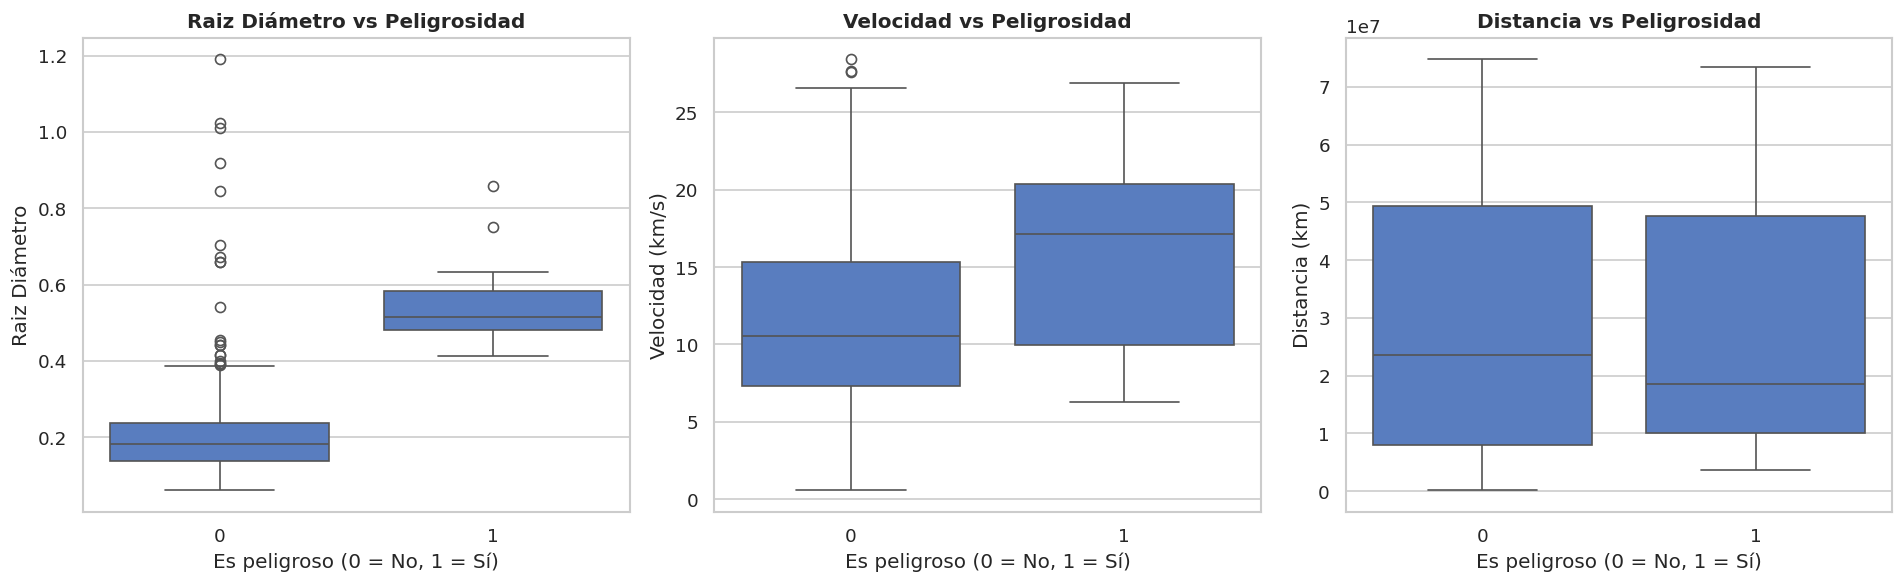

In [7]:
# ── CELDA 6: Boxplots por categoría (modelo raiz) ────────────

# Asegurar variable numérica
if 'es_peligroso_num' not in df.columns:
    df['es_peligroso_num'] = df['es_peligroso'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='es_peligroso_num', y='raiz_diametro_promedio',
            ax=axes[0])
axes[0].set_title('Raiz Diámetro vs Peligrosidad', fontweight='bold')
axes[0].set_xlabel('Es peligroso (0 = No, 1 = Sí)')
axes[0].set_ylabel('Raiz Diámetro')

sns.boxplot(data=df, x='es_peligroso_num', y='velocidad_km_s',
            ax=axes[1])
axes[1].set_title('Velocidad vs Peligrosidad', fontweight='bold')
axes[1].set_xlabel('Es peligroso (0 = No, 1 = Sí)')
axes[1].set_ylabel('Velocidad (km/s)')

sns.boxplot(data=df, x='es_peligroso_num', y='distancia_km',
            ax=axes[2])
axes[2].set_title('Distancia vs Peligrosidad', fontweight='bold')
axes[2].set_xlabel('Es peligroso (0 = No, 1 = Sí)')
axes[2].set_ylabel('Distancia (km)')

plt.tight_layout()
plt.show()


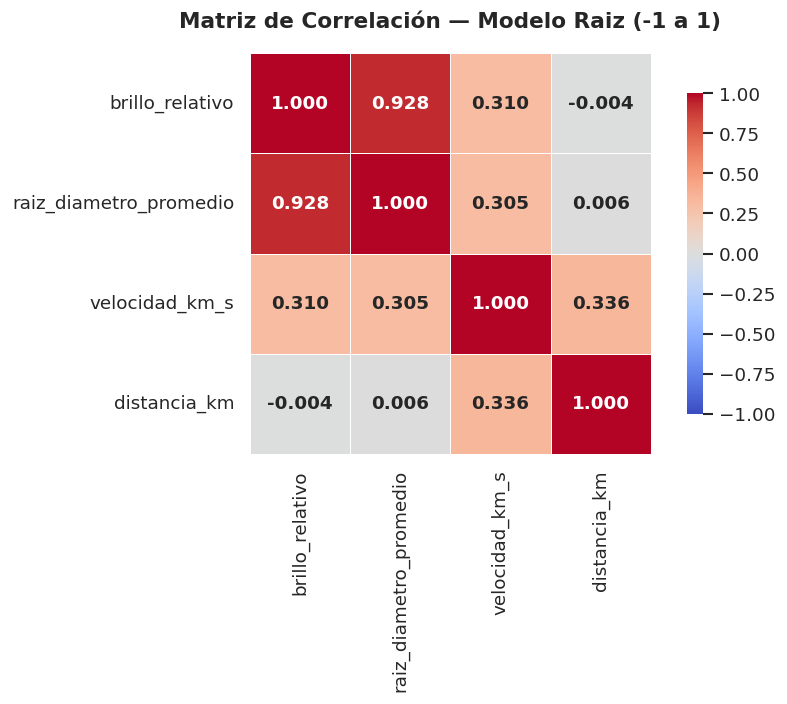


📊 Correlación con raiz_diametro_promedio:
brillo_relativo    0.9281
velocidad_km_s     0.3052
distancia_km       0.0058
Name: raiz_diametro_promedio, dtype: float64


In [8]:
# ── CELDA 7: Matriz de correlación (modelo raiz) ──────────────

# 🔹 1. Variables para correlación (modelo raiz)
vars_modelo = [
    'brillo_relativo',
    'raiz_diametro_promedio',
    'velocidad_km_s',
    'distancia_km'
]

corr = df[vars_modelo].corr()

# 🔹 2. Heatmap con escala fija [-1, 1]
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 11, 'weight': 'bold'}
)

plt.title('Matriz de Correlación — Modelo Raiz (-1 a 1)',
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# 🔹 3. Correlación con variable objetivo (Raiz)
print("\n📊 Correlación con raiz_diametro_promedio:")
print(
    corr['raiz_diametro_promedio']
    .drop('raiz_diametro_promedio')
    .sort_values(ascending=False)
    .round(4)
)

In [9]:
df[['brillo_relativo', 'raiz_diametro_promedio']].corr()

,brillo_relativo,raiz_diametro_promedio
brillo_relativo,1.000000,0.928093
raiz_diametro_promedio,0.928093,1.000000


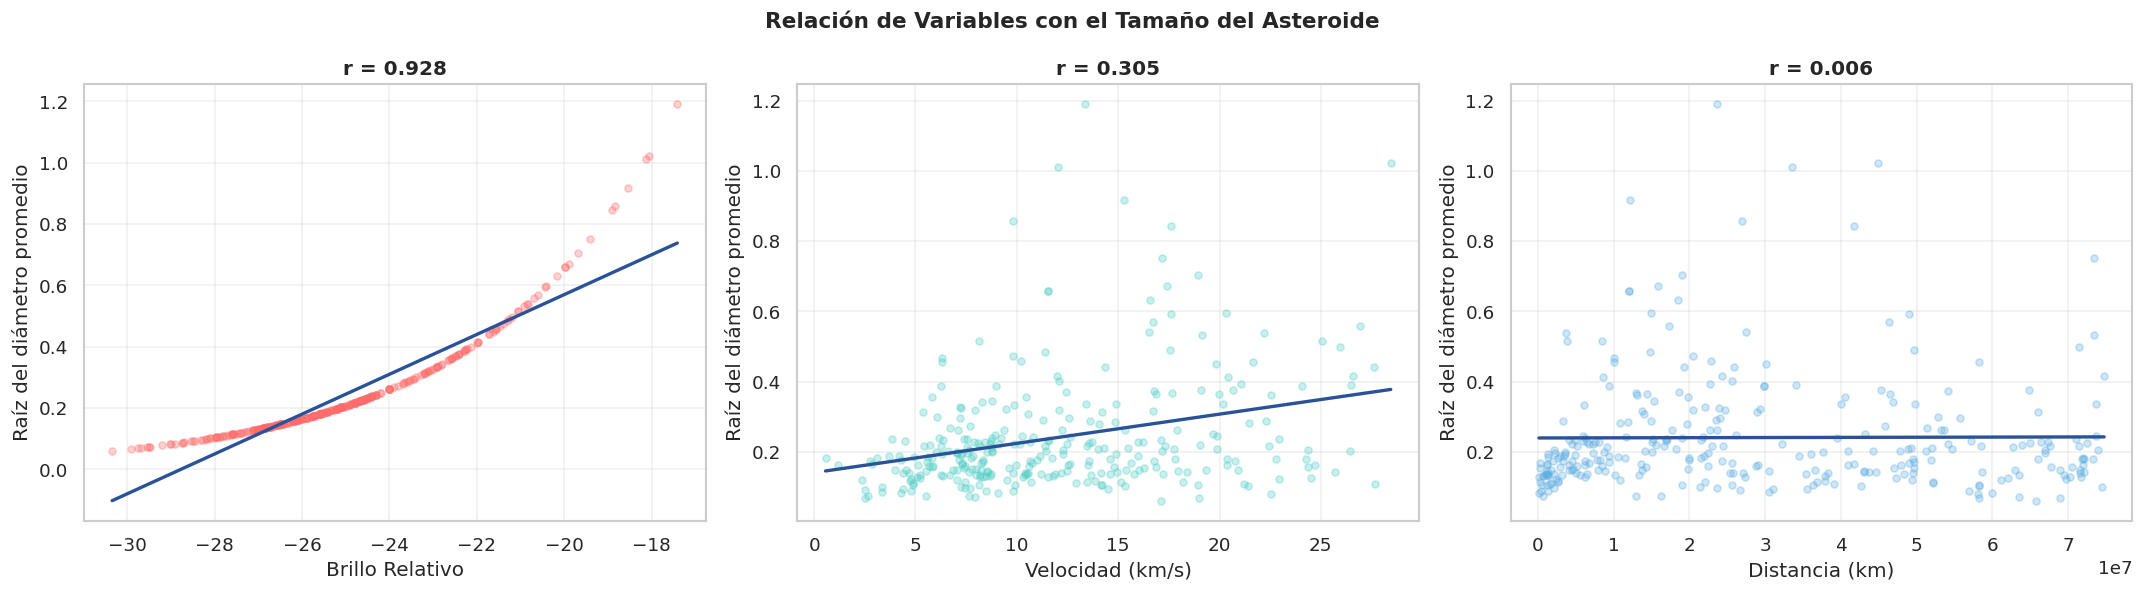

In [10]:
# ── CELDA 8: Scatter plots vs diámetro promedio (con raíz) ──────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Variables con el Tamaño del Asteroide',
             fontsize=13, fontweight='bold')

pares = [
    ('brillo_relativo', 'Brillo Relativo', '#ff6b6b'),
    ('velocidad_km_s', 'Velocidad (km/s)', '#4ecdc4'),
    ('distancia_km', 'Distancia (km)', '#5dade2'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    
    ax.scatter(df[feature], df['raiz_diametro_promedio'],
               alpha=0.3, s=18, color=color)
    
    # Línea de tendencia (regresión lineal simple)
    z = np.polyfit(df[feature], df['raiz_diametro_promedio'], 1)
    p = np.poly1d(z)
    
    xp = np.linspace(df[feature].min(), df[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    
    # Correlación
    r = df[[feature, 'raiz_diametro_promedio']].corr().iloc[0, 1]
    
    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Raíz del diámetro promedio')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# ── CELDA 9: Split Train / Test (Modelo Simple con raíz) ───────────────

# Variable independiente (X) y dependiente (y)
X_simple = df[['brillo_relativo']].values
y = df['raiz_diametro_promedio'].values  # ← aquí el cambio

# División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print("📊 División de datos:")
print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(y)*100:.0f}%)")

📊 División de datos:
Train: 240 muestras (80%)
Test : 60 muestras (20%)


In [12]:
# ── CELDA 10: Entrenamiento del modelo simple ────────────────

# Crear modelo
modelo_simple = LinearRegression()

# Entrenar
modelo_simple.fit(X_train, y_train)

# Coeficientes
beta_0 = modelo_simple.intercept_
beta_1 = modelo_simple.coef_[0]

print("📈 MODELO DE REGRESIÓN LINEAL SIMPLE")
print(f"Intercepto (β₀): {beta_0:.6f}")
print(f"Pendiente  (β₁): {beta_1:.6f}")

📈 MODELO DE REGRESIÓN LINEAL SIMPLE
Intercepto (β₀): 1.865439
Pendiente  (β₁): 0.064840


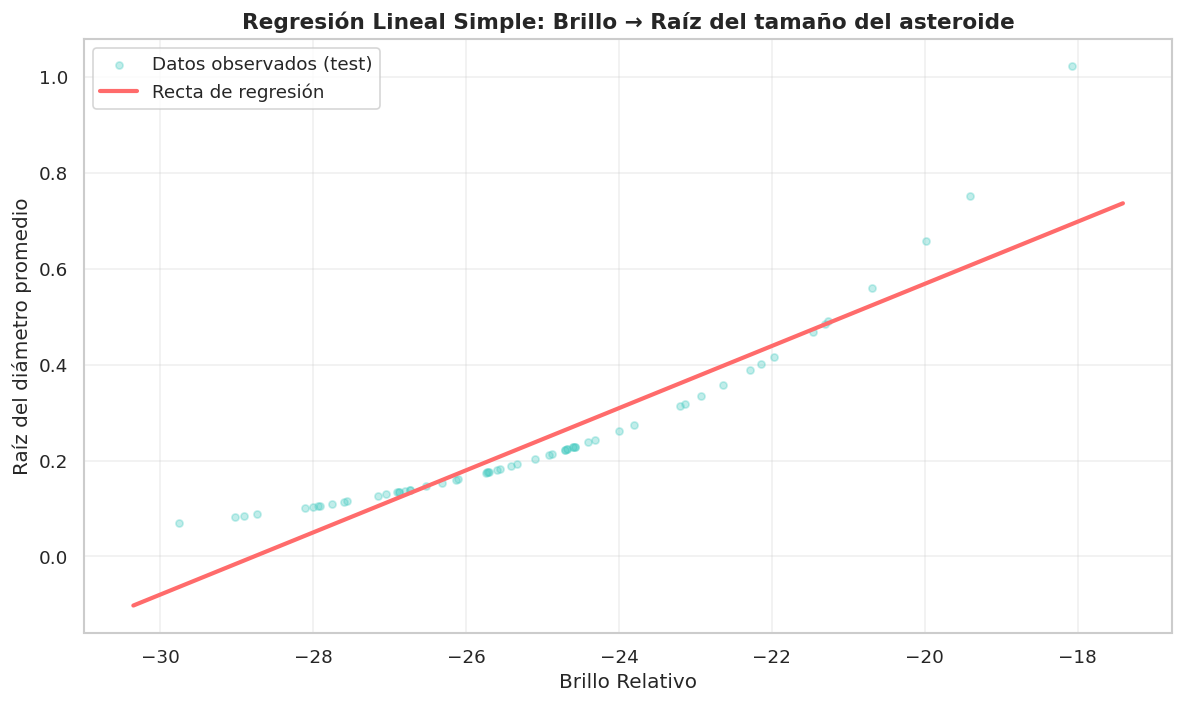

In [13]:
# ── CELDA 11: Recta de regresión (con raíz) ─────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

# Puntos reales (test)
ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')

# Línea de regresión
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)

ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

# Etiquetas ajustadas
ax.set_xlabel('Brillo Relativo', fontsize=12)
ax.set_ylabel('Raíz del diámetro promedio', fontsize=12)

ax.set_title('Regresión Lineal Simple: Brillo → Raíz del tamaño del asteroide',
             fontsize=13, fontweight='bold')

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ── CELDA 12: Métricas en escala real (diámetro) ─────────────

# Predicciones en raíz
y_pred_simple = modelo_simple.predict(X_test)

# Volver a escala real
y_test_real = y_test**2
y_pred_real = y_pred_simple**2

# Métricas
r2   = r2_score(y_test_real, y_pred_real)
mse  = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_real, y_pred_real)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE (ESCALA REAL)")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med) : {mse:.4f}")
print(f"  RMSE (raíz del MSE)         : {rmse:.4f} km")
print(f"  MAE  (error absoluto medio) : {mae:.4f} km")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE (ESCALA REAL)
  R²   (coef. determinación)  : 0.7536  (75.36%)
  MSE  (error cuadrático med) : 0.0064
  RMSE (raíz del MSE)         : 0.0801 km
  MAE  (error absoluto medio) : 0.0272 km


In [15]:
# ── CELDA 13: OLS statsmodels — resumen completo (con raíz) ─────────────

# Variable independiente (con constante)
X_ols = sm.add_constant(df['brillo_relativo'])

# Variable dependiente (raíz del diámetro)
y_ols = df['raiz_diametro_promedio']

# Modelo OLS
modelo_ols_simple = sm.OLS(y_ols, X_ols).fit()

# Resumen completo
print(modelo_ols_simple.summary())

                              OLS Regression Results                              
Dep. Variable:     raiz_diametro_promedio   R-squared:                       0.861
Model:                                OLS   Adj. R-squared:                  0.861
Method:                     Least Squares   F-statistic:                     1851.
Date:                    Fri, 17 Apr 2026   Prob (F-statistic):          6.92e-130
Time:                            18:15:27   Log-Likelihood:                 410.29
No. Observations:                     300   AIC:                            -816.6
Df Residuals:                         298   BIC:                            -809.2
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
co

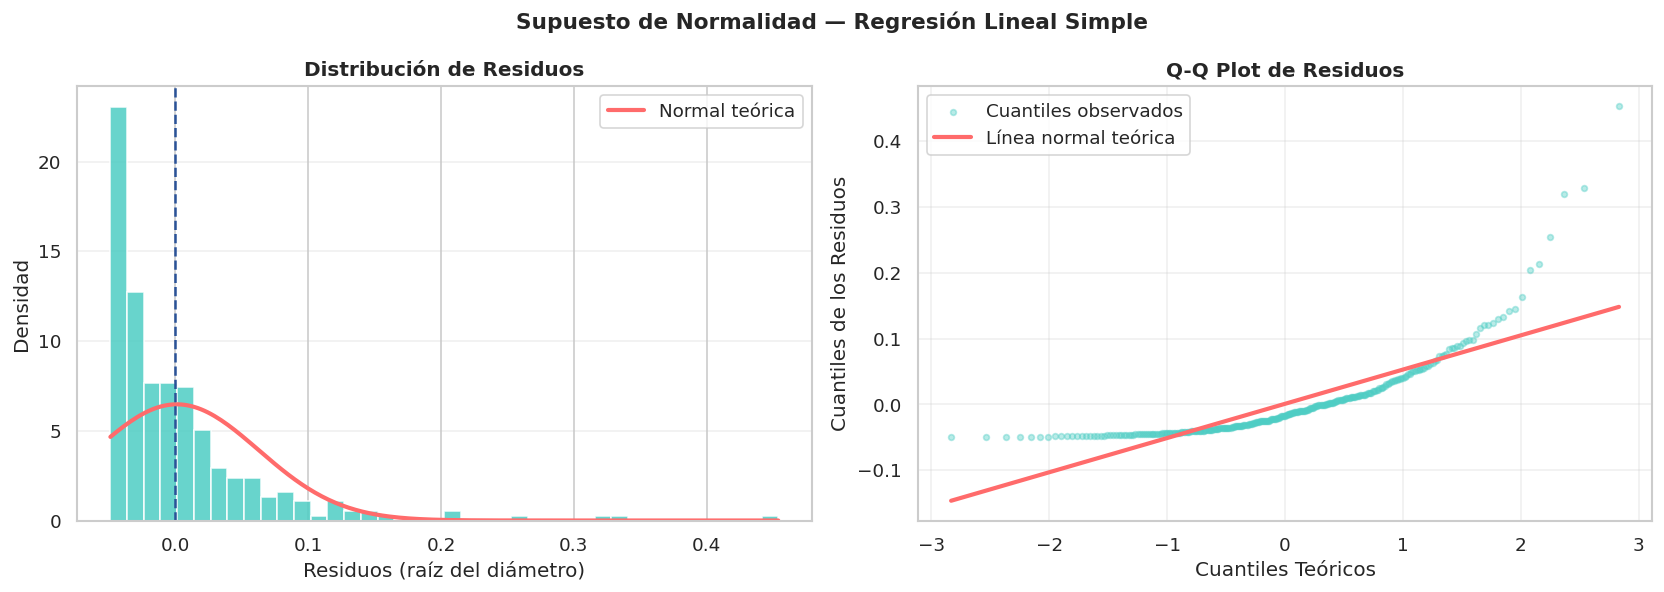


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.7058
   p-value       : 0.000000
   Conclusión    : ⚠️ Se rechaza normalidad (p ≤ 0.05)
   Nota          : En muestras grandes, Shapiro-Wilk es muy sensible;
                   por eso también se interpreta el Q-Q Plot.


In [16]:
# ── CELDA 14: Normalidad de residuos (modelo simple con raíz) ─────────

# Predicciones sobre todo el dataset
y_pred_all = modelo_simple.predict(df[['brillo_relativo']].values)

# Residuos en escala de raíz
residuos = df['raiz_diametro_promedio'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple',
             fontsize=13, fontweight='bold')

# Histograma con curva normal teórica
axes[0].hist(residuos, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)

xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')

axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (raíz del diámetro)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Test Shapiro-Wilk
muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000, replace=False))

stat_sw, p_sw = stats.shapiro(muestra_sw)

print("\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")

if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️ Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota          : En muestras grandes, Shapiro-Wilk es muy sensible;")
    print("                   por eso también se interpreta el Q-Q Plot.")

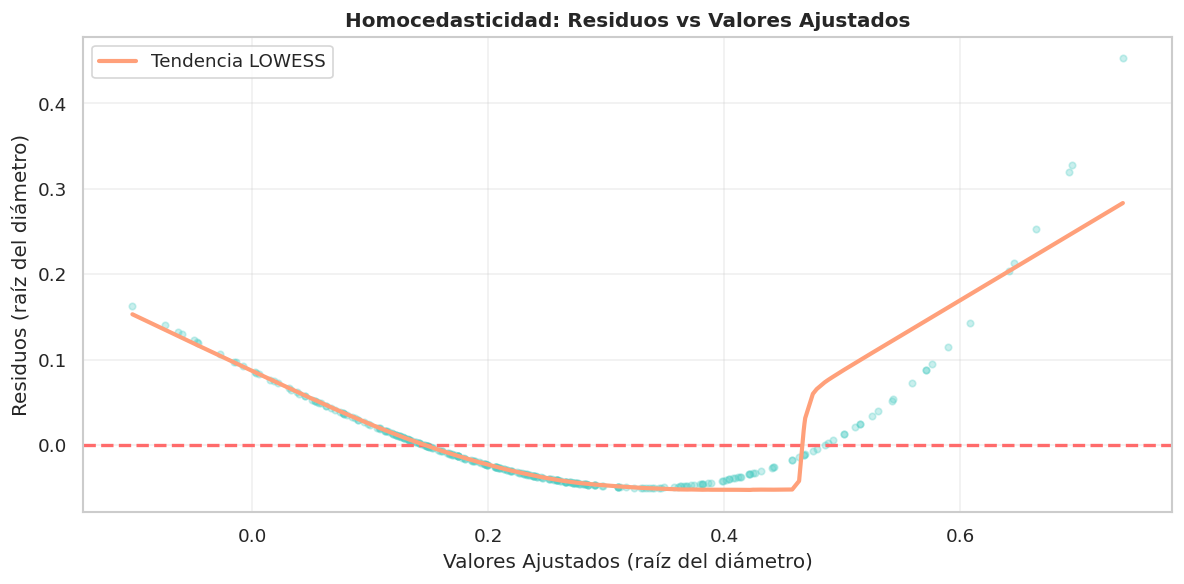


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 31.0022
   p-value        : 0.000000
   Conclusión     : ⚠️ Heterocedasticidad detectada (p ≤ 0.05)


In [17]:
# ── CELDA 15: Homocedasticidad (modelo simple con raíz) ───────────────

residuos_ols = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.30, s=15, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

# Línea LOWESS para ver tendencia
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')

plt.xlabel('Valores Ajustados (raíz del diámetro)', fontsize=12)
plt.ylabel('Residuos (raíz del diámetro)', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados',
          fontsize=12, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Test de Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print("\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")

if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️ Heterocedasticidad detectada (p ≤ 0.05)")

In [18]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple (con raíz) ──

FEATURES = ['brillo_relativo', 'velocidad_km_s', 'distancia_km']

X_multi = df[FEATURES]
y = df['raiz_diametro_promedio'].values  # ← cambio aquí

# División train/test
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

# Estandarización de variables predictoras
scaler = StandardScaler()
X_train_m_scaled = scaler.fit_transform(X_train_m)
X_test_m_scaled = scaler.transform(X_test_m)

# Entrenamiento del modelo
modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m_scaled, y_train_m)

# Predicciones
y_pred_multi = modelo_multi.predict(X_test_m_scaled)

print("📈 MODELO DE REGRESIÓN LINEAL MÚLTIPLE (con raíz)")
print(f"Intercepto β₀ : {modelo_multi.intercept_:.6f}")
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>16} : {coef:.6f}")

📈 MODELO DE REGRESIÓN LINEAL MÚLTIPLE (con raíz)
Intercepto β₀ : 0.239619
Coeficiente  brillo_relativo : 0.151747
Coeficiente   velocidad_km_s : -0.000870
Coeficiente     distancia_km : 0.000455


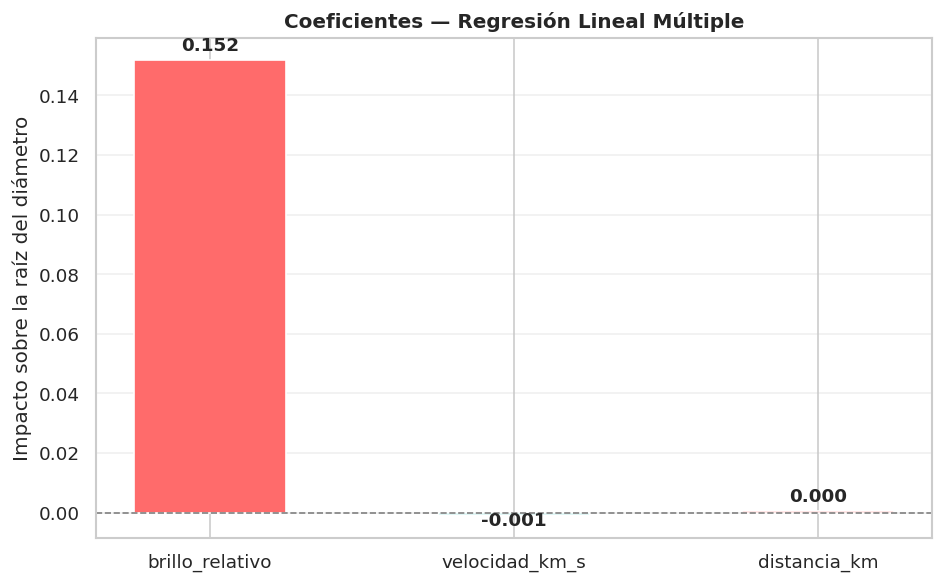

In [19]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────

colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_title('Coeficientes — Regresión Lineal Múltiple',
             fontsize=12, fontweight='bold')

# 🔧 Ajuste aquí
ax.set_ylabel('Impacto sobre la raíz del diámetro')

# Etiquetas de los valores
for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.002 if coef >= 0 else -0.005
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────

r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 48)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático med) : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)         : {rmse_m:.4f}")
print(f"  MAE  (error absoluto medio) : {mae_m:.4f}")
print("=" * 48)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   (coef. determinación)  : 0.8655  (86.55%)
  MSE  (error cuadrático med) : 0.0041
  RMSE (raíz del MSE)         : 0.0638
  MAE  (error absoluto medio) : 0.0432


In [21]:
# ── CELDA 19: OLS statsmodels — modelo múltiple (con raíz) ──────────────

# Variables independientes (sin escalar para interpretación)
X_ols_m = sm.add_constant(df[FEATURES])

# Variable dependiente (raíz del diámetro)
y_ols_m = df['raiz_diametro_promedio']

# Modelo OLS múltiple
modelo_ols_multi = sm.OLS(y_ols_m, X_ols_m).fit()

# Resumen completo
print(modelo_ols_multi.summary())

                              OLS Regression Results                              
Dep. Variable:     raiz_diametro_promedio   R-squared:                       0.862
Model:                                OLS   Adj. R-squared:                  0.860
Method:                     Least Squares   F-statistic:                     614.9
Date:                    Fri, 17 Apr 2026   Prob (F-statistic):          8.65e-127
Time:                            18:15:29   Log-Likelihood:                 410.69
No. Observations:                     300   AIC:                            -813.4
Df Residuals:                         296   BIC:                            -798.6
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
co

In [22]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────

X_vif = df[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_data["VIF"] = vif_data["VIF"].round(3)

vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
              if v < 5
              else ("⚠️ Moderada (5 ≤ VIF < 10)"
                    if v < 10
                    else "❌ Severa (VIF ≥ 10)")
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
       Variable   VIF                          Criterio
brillo_relativo 4.672 ✅ Sin multicolinealidad (VIF < 5)
 velocidad_km_s 4.936 ✅ Sin multicolinealidad (VIF < 5)
   distancia_km 2.944 ✅ Sin multicolinealidad (VIF < 5)


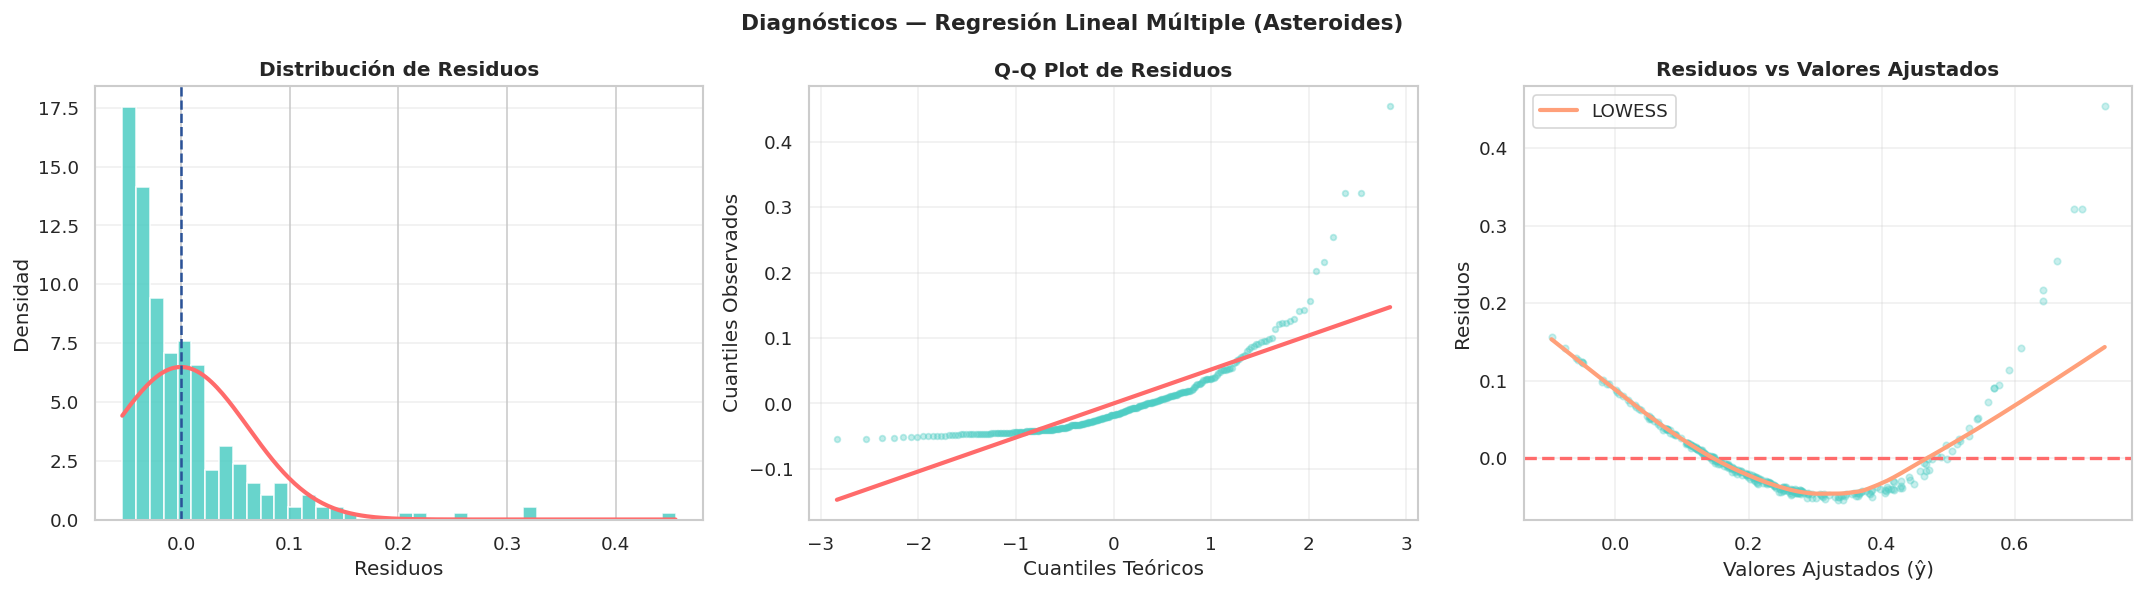


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.000000 → ⚠️ Se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.000001 → ⚠️ Heterocedasticidad detectada


In [23]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────

residuos_m = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple (Asteroides)',
             fontsize=13, fontweight='bold')

# ── Histograma de residuos
axes[0].hist(residuos_m, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# ── Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i,
             color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Tests estadísticos
muestra_m = (residuos_m if len(residuos_m) <= 5000
             else np.random.default_rng(42).choice(residuos_m, 5000, replace=False))

stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(
    modelo_ols_multi.resid,
    modelo_ols_multi.model.exog
)

print("\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   p-value: {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️ Se rechaza normalidad'}")

print("\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"   p-value: {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️ Heterocedasticidad detectada'}")

In [24]:
# ── CELDA 22: Comparación final de modelos ───────────────────

comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': [
        'brillo_relativo',
        'brillo_relativo + velocidad_km_s + distancia_km'
    ],
    'R²'       : [round(r2, 4),    round(r2_m, 4)],
    'R² Aj.'   : [
        round(modelo_ols_simple.rsquared_adj, 4),
        round(modelo_ols_multi.rsquared_adj, 4)
    ],
    'RMSE'     : [round(rmse, 4),  round(rmse_m, 4)],
    'MAE'      : [round(mae, 4),   round(mae_m, 4)],
    'AIC'      : [
        round(modelo_ols_simple.aic, 2),
        round(modelo_ols_multi.aic, 2)
    ],
    'BIC'      : [
        round(modelo_ols_simple.bic, 2),
        round(modelo_ols_multi.bic, 2)
    ],
})

print("=" * 80)
print("              COMPARACIÓN DE MODELOS")
print("=" * 80)
print(comparacion.to_string(index=False))
print("=" * 80)

print("\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y complejidad")

              COMPARACIÓN DE MODELOS
            Modelo                                       Variables     R²  R² Aj.   RMSE    MAE     AIC     BIC
  Regresión Simple                                 brillo_relativo 0.7536  0.8609 0.0801 0.0272 -816.57 -809.17
Regresión Múltiple brillo_relativo + velocidad_km_s + distancia_km 0.8655  0.8603 0.0638 0.0432 -813.37 -798.56

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y complejidad


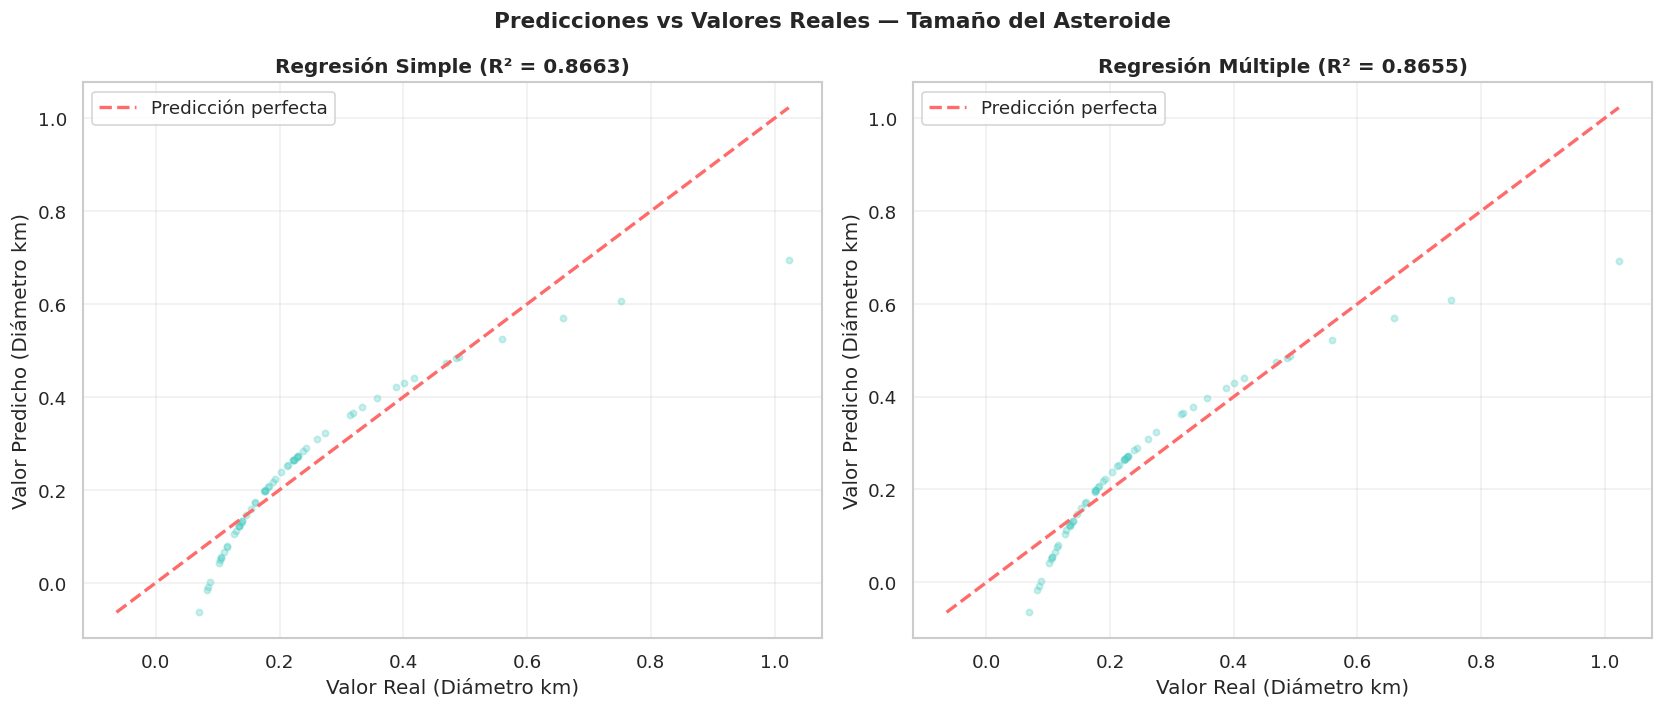

In [25]:
# ── CELDA 23: Predicciones vs Reales — ambos modelos ─────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales — Tamaño del Asteroide',
             fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):
    
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())

    ax.scatter(y_real, y_pred, alpha=0.30, s=14, color='#4ecdc4')

    # Línea de predicción perfecta
    ax.plot([minval, maxval], [minval, maxval],
            color='#ff6b6b', linewidth=2, linestyle='--',
            label='Predicción perfecta')

    r2_val = r2_score(y_real, y_pred)

    ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')
    ax.set_xlabel('Valor Real (Diámetro km)')
    ax.set_ylabel('Valor Predicho (Diámetro km)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()